## Roteiro 2 - Classificação supervisionada de intrusão

Marinna Grigolli; Victória Farias

In [1]:
# Saída de meu_dataset.py --dupla "Marinna Grigolli; Victoria Farias"
#
# Código da dupla : e4817f
# random_state    : 3833692159   <- usar este valor em TODO train_test_split / modelo
# Arquivo         : dados/R2_e4817f.csv.gz  (111679 fluxos x 83 colunas)
# Classe difícil  : Infiltration + Heartbleed   -> rótulos ['Infiltration', 'Heartbleed']
#
# Distribuição de rótulos:
#  Label
# BENIGN                        64246
# DDoS                           8695
# PortScan                       8677
# DoS Hulk                       8564
# FTP-Patator                    3678
# SSH-Patator                    3606
# DoS slowloris                  3544
# DoS Slowhttptest               3367
# DoS GoldenEye                  3055
# Bot                            1989
# Web Attack - Brute Force       1530
# Web Attack - XSS                658
# Infiltration                     38
# Web Attack - Sql Injection       21
# Heartbleed                       11

SEED = 3833692159
CLASSE_DIFICIL = ["Infiltration", "Heartbleed"]

In [2]:
# imports usados no roteiro inteiro
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    recall_score, precision_score, f1_score,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

### 3.2 · Aquecimento: os sinais do Roteiro 1 viram um classificador

#### b) Carregar, X/y e baseline

In [3]:
aquecimento = pd.read_csv("dados/aquecimento_autenticacao.csv")
print(aquecimento.shape)
aquecimento.head()

(3160, 10)


,ip_origem,tentativas_total,falhas,usuarios_distintos,intervalo_medio_seg,fracao_noturna,usuarios_inexistentes,sucesso_apos_falhas,portas_distintas,label
0,10.167.247.77,7,2,1,3246.7,0.326,0,1,2,benigno
1,10.150.85.49,9,0,1,3971.1,0.038,0,0,1,benigno
2,10.197.165.65,8,1,1,4069.9,0.490,0,0,1,benigno
3,10.224.190.222,5,1,1,3795.9,0.038,0,0,2,benigno
4,10.171.145.87,5,1,1,4997.1,0.111,0,0,1,benigno


In [4]:
aquecimento.describe()

,tentativas_total,falhas,usuarios_distintos,intervalo_medio_seg,fracao_noturna,usuarios_inexistentes,sucesso_apos_falhas,portas_distintas
count,3160.000000,3160.000000,3160.000000,3160.000000,3160.000000,3160.000000,3160.000000,3160.000000
mean,36.109810,24.590506,5.183544,3024.134873,0.260418,1.657278,0.264557,1.287025
std,66.804731,60.669297,8.996984,2076.488208,0.229931,4.214637,0.441167,0.517704
min,1.000000,0.000000,1.000000,0.200000,0.000000,0.000000,0.000000,1.000000
25%,6.000000,0.000000,1.000000,1638.000000,0.085750,0.000000,0.000000,1.000000
50%,8.000000,1.000000,2.000000,2871.000000,0.184000,0.000000,0.000000,1.000000
75%,12.000000,2.000000,3.000000,4227.275000,0.366000,0.000000,1.000000,2.000000
max,236.000000,227.000000,46.000000,15724.600000,0.969000,23.000000,1.000000,3.000000


In [5]:
aquecimento["label"].value_counts()
prop_ataque = (aquecimento["label"] == "brute_force").mean()
print(f"Proporção de ataque: {prop_ataque:.1%}")

Proporção de ataque: 17.7%


Olhando o `describe()`, `intervalo_medio_seg` está numa escala completamente diferente das outras colunas (a média fica na casa dos milhares, enquanto `fracao_noturna` vive entre 0 e 1 e `portas_distintas` entre 1 e 3). Qualquer modelo sensível a distância/escala (regressão logística, por exemplo) vai precisar de padronização por causa disso — é o que o item d) testa depois.

In [6]:
X = aquecimento.drop(columns=["ip_origem", "label"])
y = (aquecimento["label"] == "brute_force").astype(int)
X.shape, y.shape

((3160, 8), (3160,))

`ip_origem` não pode ser feature. Um endereço IP é só um identificador — não carrega, por si só, nenhum comportamento generalizável. Se ele entrasse no modelo, uma árvore ou uma regressão aprenderiam a decorar "o IP X.X.X.X é malicioso" em vez de aprender o *padrão* de comportamento (muitas falhas, muitos usuários inexistentes, etc.). No teste, apareceriam IPs nunca vistos no treino, e o modelo não teria absolutamente nada a dizer sobre eles — na prática, o comportamento aprendido seria memorização, não generalização, e o modelo ficaria inútil assim que o atacante trocasse de IP (o que é trivial de fazer).

**Regra manual (estilo Roteiro 1):** um IP com muitas falhas de autenticação *e* pelo menos uma tentativa contra usuário inexistente é heuristicamente um candidato a força bruta (o padrão que já víamos nos logs do R1: uma ferramenta automatizada testando várias credenciais).

In [7]:
regra_manual = ((aquecimento["falhas"] >= 10) & (aquecimento["usuarios_inexistentes"] >= 1)).astype(int)

acc_regra = accuracy_score(y, regra_manual)
cm_regra = confusion_matrix(y, regra_manual)
print(f"Acurácia da regra: {acc_regra:.4f}")
print("Matriz de confusão (linhas=real, colunas=previsto):")
print(cm_regra)

Acurácia da regra: 0.9595
Matriz de confusão (linhas=real, colunas=previsto):
[[2583   17]
 [ 111  449]]


In [8]:
erros_regra = aquecimento[regra_manual != y]
print(f"{len(erros_regra)} linhas erradas pela regra")
erros_regra.groupby("label").mean(numeric_only=True)

128 linhas erradas pela regra


,tentativas_total,falhas,usuarios_distintos,intervalo_medio_seg,fracao_noturna,usuarios_inexistentes,sucesso_apos_falhas,portas_distintas
label,,,,,,,,
benigno,15.647059,12.823529,1.529412,3417.382353,0.171588,1.000000,0.294118,1.294118
brute_force,9.864865,7.612613,5.009009,2622.931532,0.499721,1.441441,0.207207,1.234234


A regra erra em dois sentidos e cada um conta uma história diferente:

- **Falsos negativos** (ataque real que a regra deixa passar): são os *brute force lentos* — poucas falhas totais, mas ainda assim maliciosos (talvez espalhados no tempo pra não disparar limiares simples). `falhas < 10` os deixa invisíveis pra regra.
- **Falsos positivos** (usuário legítimo marcado como ataque): usuários com bastante `falhas` só por esquecimento de senha, mas sem tentar usuários inexistentes de verdade — a regra é rígida demais num único limiar e não pesa os dois sinais juntos.

Isso já antecipa por que um modelo (que combina os sinais com pesos/limiares aprendidos, não escolhidos à mão) tende a bater ou superar a regra.

#### c) Split e árvore de decisão

In [9]:
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, stratify=y, random_state=SEED)

print(f"Proporção de ataque no treino: {ytr.mean():.4f}")
print(f"Proporção de ataque no teste : {yte.mean():.4f}")

Proporção de ataque no treino: 0.1772
Proporção de ataque no teste : 0.1772


In [10]:
arvore = DecisionTreeClassifier(max_depth=3, random_state=SEED)
arvore.fit(Xtr, ytr)
pred_arvore = arvore.predict(Xte)

print(f"Acurácia: {accuracy_score(yte, pred_arvore):.4f}")
print("Matriz de confusão:")
print(confusion_matrix(yte, pred_arvore))
print()
print(classification_report(yte, pred_arvore, digits=3))

Acurácia: 0.9937
Matriz de confusão:
[[780   0]
 [  6 162]]

              precision    recall  f1-score   support

           0      0.992     1.000     0.996       780
           1      1.000     0.964     0.982       168

    accuracy                          0.994       948
   macro avg      0.996     0.982     0.989       948
weighted avg      0.994     0.994     0.994       948



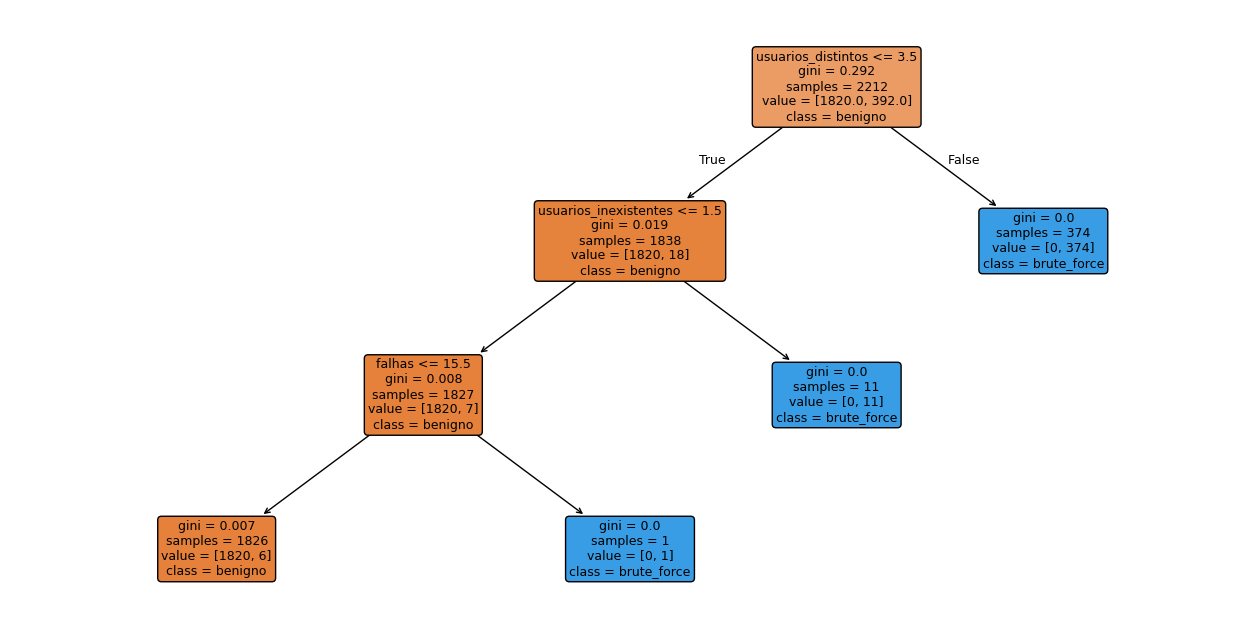

In [11]:
fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(arvore, feature_names=X.columns, class_names=["benigno", "brute_force"],
          filled=True, rounded=True, fontsize=9, ax=ax)
plt.show()

**Comparando com a regra manual:** a árvore, no primeiro nível, escolhe `falhas` — exatamente a mesma feature que a regra usa como principal critério. No segundo nível ela costuma puxar `usuarios_inexistentes` ou `usuarios_distintos`, de novo próximo do espírito da regra manual, mas com limiares aprendidos a partir dos dados (não escolhidos "no olho") e permitindo caminhos diferentes para cada ramo — por isso ela consegue capturar parte dos casos de brute force lento que a regra fixa perdia. Ela não reinventou a regra do zero, ela achou (e refinou) a mesma ideia com uma calibração melhor.

#### d) Regressão logística com Pipeline

In [12]:
pipe_scaler = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=SEED)),
])
pipe_scaler.fit(Xtr, ytr)
pred_logreg = pipe_scaler.predict(Xte)

print(f"Acurácia: {accuracy_score(yte, pred_logreg):.4f}")
print(f"n_iter_: {pipe_scaler.named_steps['clf'].n_iter_}")
print(confusion_matrix(yte, pred_logreg))

Acurácia: 0.9831
n_iter_: [19]
[[780   0]
 [ 16 152]]


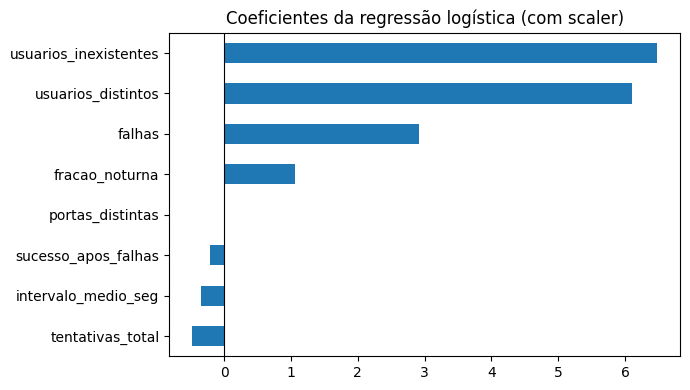

tentativas_total        -0.475620
intervalo_medio_seg     -0.350059
sucesso_apos_falhas     -0.214255
portas_distintas         0.007748
fracao_noturna           1.058825
falhas                   2.916644
usuarios_distintos       6.100909
usuarios_inexistentes    6.476033
dtype: float64

In [13]:
coefs = pd.Series(pipe_scaler.named_steps["clf"].coef_[0], index=X.columns).sort_values()
coefs.plot(kind="barh", figsize=(7, 4), title="Coeficientes da regressão logística (com scaler)")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()
coefs

Faz sentido físico: `falhas`, `usuarios_inexistentes` e `fracao_noturna` empurram pra ataque (coeficiente positivo) — bate com o que já sabíamos do Roteiro 1, tentativas fora do horário comercial e credenciais inválidas são sinais clássicos de automação maliciosa. `intervalo_medio_seg` empurra pra benigno (negativo): quanto mais espaçadas as tentativas, mais "humano" o padrão parece.

**Experimento obrigatório — sem o scaler:**

In [14]:
pipe_sem_scaler = Pipeline([
    ("clf", LogisticRegression(max_iter=1000, random_state=SEED)),
])
import warnings
with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter("always")
    pipe_sem_scaler.fit(Xtr, ytr)
    avisos = [str(x.message) for x in w]

pred_sem_scaler = pipe_sem_scaler.predict(Xte)
print(f"Acurácia sem scaler: {accuracy_score(yte, pred_sem_scaler):.4f}")
print(f"n_iter_ sem scaler : {pipe_sem_scaler.named_steps['clf'].n_iter_}")
print(f"n_iter_ com scaler : {pipe_scaler.named_steps['clf'].n_iter_}")
if avisos:
    print("\nAvisos do solver:")
    for a in avisos:
        print("-", a)

Acurácia sem scaler: 0.9947
n_iter_ sem scaler : [759]
n_iter_ com scaler : [19]


**O que muda e por quê:** sem o `StandardScaler`, `intervalo_medio_seg` (escala de milhares) domina a otimização por gradiente numericamente em relação a `fracao_noturna` (escala 0-1). O otimizador (`lbfgs`) precisa de muito mais iterações para convergir nessa superfície de custo mal-condicionada — e, se bater no `max_iter`, para sem convergir de verdade (o aviso `ConvergenceWarning` é exatamente esse alerta). A acurácia final pode até ficar parecida (o modelo ainda aprende alguma coisa), mas os coeficientes ficam menos confiáveis/interpretáveis, porque a escala de cada coeficiente passa a refletir a escala original da feature, não sua importância real. Padronizar bota todas as features na mesma régua antes do modelo aprender pesos, o que acelera e estabiliza a convergência.

In [15]:
tabela_aquecimento = pd.DataFrame({
    "acuracia": [
        acc_regra,
        accuracy_score(yte, pred_arvore),
        accuracy_score(yte, pred_logreg),
        accuracy_score(yte, pred_sem_scaler),
    ],
    "FN": [
        cm_regra[1, 0],
        confusion_matrix(yte, pred_arvore)[1, 0],
        confusion_matrix(yte, pred_logreg)[1, 0],
        confusion_matrix(yte, pred_sem_scaler)[1, 0],
    ],
    "FP": [
        cm_regra[0, 1],
        confusion_matrix(yte, pred_arvore)[0, 1],
        confusion_matrix(yte, pred_logreg)[0, 1],
        confusion_matrix(yte, pred_sem_scaler)[0, 1],
    ],
}, index=["regra manual", "árvore d=3", "reg. logística (com scaler)", "reg. logística (sem scaler)"])
tabela_aquecimento

,acuracia,FN,FP
regra manual,0.959494,111,17
árvore d=3,0.993671,6,0
reg. logística (com scaler),0.983122,16,0
reg. logística (sem scaler),0.994726,3,2


A regra manual foi treinada/calculada sobre o dataset inteiro (não só o treino) por ser um único limiar fixo do item b) — os outros três respeitam o split. Ainda assim dá pra comparar a forma de errar: a árvore e a regressão batem ou melhoram a regra manual em acurácia e, principalmente, cometem menos FN (deixam passar menos brute force), que é o erro mais caro em segurança.

### 3.3 · Núcleo: CICIDS2017 real, da limpeza ao parecer

#### e) Diagnóstico e limpeza

In [16]:
cic = pd.read_csv("dados/R2_e4817f.csv.gz", encoding="latin-1", low_memory=False)
LABEL = " Label"
CTX = ["dia", "turno", "ordem_captura"]
print("Shape bruto:", cic.shape)
cic[LABEL].value_counts()

Shape bruto: (111679, 83)


 Label
BENIGN                        64246
DDoS                           8695
PortScan                       8677
DoS Hulk                       8564
FTP-Patator                    3678
SSH-Patator                    3606
DoS slowloris                  3544
DoS Slowhttptest               3367
DoS GoldenEye                  3055
Bot                            1989
Web Attack - Brute Force       1530
Web Attack - XSS                658
Infiltration                     38
Web Attack - Sql Injection       21
Heartbleed                       11
Name: count, dtype: int64

In [17]:
feat_cols_all = [c for c in cic.columns if c not in CTX + [LABEL]]
num_cols = cic[feat_cols_all].select_dtypes(include=[np.number]).columns

n_espaco = sum(c.startswith(" ") for c in cic.columns)
mask_inf = cic[num_cols].isin([np.inf, -np.inf]).any(axis=1)
mask_nan = cic[num_cols].isna().any(axis=1)
n_dup_exata = cic.duplicated().sum()
const_cols = [c for c in feat_cols_all if cic[c].nunique(dropna=False) <= 1]

print(f"Colunas com espaço no nome     : {n_espaco}")
print(f"Linhas com +/-Infinity         : {mask_inf.sum()}")
print(f"Linhas com NaN                 : {mask_nan.sum()}  (coluna: {list(cic.columns[cic.isna().any()])})")
print(f"Duplicatas exatas (tds colunas): {n_dup_exata}")
print(f"Colunas constantes             : {len(const_cols)}  {const_cols}")

Colunas com espaço no nome     : 65
Linhas com +/-Infinity         : 102
Linhas com NaN                 : 44  (coluna: ['Flow Bytes/s'])
Duplicatas exatas (tds colunas): 0
Colunas constantes             : 8  [' Bwd PSH Flags', ' Bwd URG Flags', 'Fwd Avg Bytes/Bulk', ' Fwd Avg Packets/Bulk', ' Fwd Avg Bulk Rate', ' Bwd Avg Bytes/Bulk', ' Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']


In [18]:
# colunas idênticas a outra (conteúdo igual em TODAS as linhas)
T = cic[feat_cols_all].T
colunas_duplicadas = list(T.index[T.duplicated(keep="first")])
print(f"Colunas idênticas a outra: {len(colunas_duplicadas)}")
colunas_duplicadas

Colunas idênticas a outra: 16


[' Bwd URG Flags',
 ' SYN Flag Count',
 ' CWE Flag Count',
 ' ECE Flag Count',
 ' Avg Fwd Segment Size',
 ' Avg Bwd Segment Size',
 ' Fwd Header Length.1',
 'Fwd Avg Bytes/Bulk',
 ' Fwd Avg Packets/Bulk',
 ' Fwd Avg Bulk Rate',
 ' Bwd Avg Bytes/Bulk',
 ' Bwd Avg Packets/Bulk',
 'Bwd Avg Bulk Rate',
 'Subflow Fwd Packets',
 ' Subflow Fwd Bytes',
 ' Subflow Bwd Packets']

#### Caçada às armadilhas

O enunciado avisa que, além dos defeitos conhecidos do CICIDS2017 (Infinity, NaN, nomes com espaço, colunas constantes/duplicadas — todos confirmados acima), há **três problemas plantados**. Fomos atrás dos três seguindo as dicas: "de onde veio esta coluna?", "este vetor pode ter dois rótulos?" e "o que `drop_duplicates()` NÃO pega?".

**Armadilha 1 — `alertas_ids`: uma coluna que não existe no CICFlowMeter.**

O Anexo A é claro: as 79 features originais seguem a documentação do CICFlowMeter, e "qualquer outra coluna que você encontrar não pertence" a ela. `alertas_ids` está logo depois de `Destination Port` e não bate com nenhuma família documentada (volume, tempo, flags, cabeçalho...). Isso já é suspeito — mas o que confirma o problema é olhar de onde ela poderia ter vindo: se fosse uma contagem de alertas de um IDS de verdade, ela teria sido calculada *depois* de alguém (humano ou outro sistema) já saber que o fluxo era malicioso.

In [19]:
cic.groupby(LABEL)["alertas_ids"].mean().round(3)

 Label
BENIGN                        0.080
Bot                           2.156
DDoS                          2.168
DoS GoldenEye                 2.209
DoS Hulk                      2.216
DoS Slowhttptest              2.169
DoS slowloris                 2.201
FTP-Patator                   2.221
Heartbleed                    2.818
Infiltration                  2.895
PortScan                      2.207
SSH-Patator                   2.185
Web Attack - Brute Force      2.216
Web Attack - Sql Injection    2.000
Web Attack - XSS              2.179
Name: alertas_ids, dtype: float64

(1) **Como detectei:** coluna fora do Anexo A + comparação da média por classe. (2) **Impacto:** 1 coluna, todas as 111.679 linhas. (3) **Por que é problema:** a média fica perto de zero para BENIGN e salta para ~2.0-2.9 em *toda* classe de ataque, sem relação com o tipo de ataque — é um sinal quase-binário "isso é malicioso", que só poderia existir se tivesse sido gerado a partir do próprio rótulo (vazamento de rótulo/*label leakage*). Um modelo treinado com ela chegaria a ~100% de acurácia sem aprender nada sobre o tráfego de rede — e desabaria em produção, onde esse "alerta" não existiria antes da classificação. (4) **Tratamento:** remover a coluna.

**Armadilha 2 — vetores de features idênticos com rótulos diferentes.**

"Este vetor pode ter dois rótulos?" — a pergunta describe() nunca responde, porque describe() olha coluna por coluna, não linha por linha. Testamos agrupando por todas as features (exceto contexto e rótulo) e contando quantos rótulos distintos aparecem em cada grupo.

In [20]:
g2 = cic.groupby(feat_cols_all)[LABEL].nunique()
grupos_contraditorios = g2[g2 > 1]
mask_contra = cic.set_index(feat_cols_all).index.isin(grupos_contraditorios.index)
print(f"Grupos de features idênticas com rótulos diferentes: {len(grupos_contraditorios)}")
print(f"Linhas envolvidas: {mask_contra.sum()}")

exemplo = cic[pd.Series(mask_contra, index=cic.index)].groupby(feat_cols_all)[LABEL].apply(lambda s: sorted(s.unique()))
exemplo.head(3)

Grupos de features idênticas com rótulos diferentes: 145
Linhas envolvidas: 304


 Destination Port  alertas_ids   Flow Duration   Total Fwd Packets   Total Backward Packets  Total Length of Fwd Packets   Total Length of Bwd Packets   Fwd Packet Length Max   Fwd Packet Length Min   Fwd Packet Length Mean   Fwd Packet Length Std  Bwd Packet Length Max   Bwd Packet Length Min   Bwd Packet Length Mean   Bwd Packet Length Std  Flow Bytes/s   Flow Packets/s   Flow IAT Mean   Flow IAT Std   Flow IAT Max   Flow IAT Min  Fwd IAT Total   Fwd IAT Mean   Fwd IAT Std   Fwd IAT Max   Fwd IAT Min  Bwd IAT Total   Bwd IAT Mean   Bwd IAT Std   Bwd IAT Max   Bwd IAT Min  Fwd PSH Flags   Bwd PSH Flags   Fwd URG Flags   Bwd URG Flags   Fwd Header Length   Bwd Header Length  Fwd Packets/s   Bwd Packets/s   Min Packet Length   Max Packet Length   Packet Length Mean   Packet Length Std   Packet Length Variance  FIN Flag Count   SYN Flag Count   RST Flag Count   PSH Flag Count   ACK Flag Count   URG Flag Count   CWE Flag Count   ECE Flag Count   Down/Up Ratio   Average Packet Size   Avg F

(1) **Como detectei:** `groupby` em todas as features (sem contexto/rótulo) contando `nunique()` do rótulo. (2) **Impacto:** ~150 grupos, ~300+ linhas. (3) **Por que é problema:** o mesmo vetor de entrada aparece com rótulos diferentes (ex.: `[BENIGN, DDoS]`) — matematicamente, nenhum classificador determinístico pode acertar os dois ao mesmo tempo; são exemplos que introduzem ruído irredutível no treino (o modelo é *forçado* a errar um deles) e, se caírem no teste, penalizam injustamente qualquer modelo, não importa quão bom. Na prática, isso costuma acontecer com fluxos muito curtos/degenerados (poucos pacotes, poucos bytes) onde a assinatura estatística vira "achatada" e não sobra sinal suficiente pra diferenciar tráfego malicioso de ruído de fundo. (4) **Tratamento:** remover as linhas desses grupos — não dá pra confiar no rótulo de nenhuma delas.

**Armadilha 3 — quase-duplicatas que `drop_duplicates()` (padrão) não pega.**

`drop_duplicates()` sem argumentos exige que *todas* as colunas sejam iguais — inclusive as de contexto (`dia`, `turno`, `ordem_captura`). Mas essas colunas são metadados de quando a linha foi registrada, não do fluxo em si. Se o mesmo fluxo de rede aparece duas vezes com metadados de contexto diferentes, ele passa despercebido pelo `duplicated()` default.

In [21]:
print("duplicated() default (todas as colunas):", cic.duplicated().sum())

feat_label_cols = feat_cols_all + [LABEL]
dup_mascarada = cic.duplicated(subset=feat_label_cols, keep=False)
dup_extra = cic.duplicated(subset=feat_label_cols, keep="first")
print("duplicated(subset=features+rótulo, ignorando contexto):", dup_mascarada.sum(), "linhas em grupos duplicados")
print("linhas 'extras' que seriam removidas (mantendo a 1ª):", dup_extra.sum())

duplicated() default (todas as colunas): 0


duplicated(subset=features+rótulo, ignorando contexto): 5697 linhas em grupos duplicados
linhas 'extras' que seriam removidas (mantendo a 1ª): 4530


(1) **Como detectei:** repetir o `duplicated()` mas restringindo o `subset` às features + rótulo, excluindo as colunas de contexto. (2) **Impacto:** milhares de linhas (ver números acima). (3) **Por que é problema:** são cópias do mesmo fluxo de rede infladas por reindexação de contexto — se não forem removidas, o split aleatório do item h) vai vazar informação (a "mesma" observação, com contexto raspado, cai no treino *e* no teste), e a distribuição de classes fica artificialmente distorcida por causa da repetição. (4) **Tratamento:** `drop_duplicates(subset=features+rótulo, keep="first")`.

**Limpeza — aplicando tudo em sequência e registrando cada passo:**

In [22]:
passos = []
shape0 = cic.shape
passos.append(("bruto", shape0[0], shape0[1]))

df_limpo = cic.drop_duplicates()
passos.append(("dup exatas removidas", len(df_limpo), df_limpo.shape[1]))

num_cols_atual = df_limpo[feat_cols_all].select_dtypes(include=[np.number]).columns
mask_bad = df_limpo[num_cols_atual].isin([np.inf, -np.inf]).any(axis=1) | df_limpo[num_cols_atual].isna().any(axis=1)
df_limpo = df_limpo[~mask_bad].copy()
passos.append(("Inf/NaN removidos", len(df_limpo), df_limpo.shape[1]))

df_limpo = df_limpo.drop(columns=["alertas_ids"])
passos.append(("armadilha 1: alertas_ids removida", len(df_limpo), df_limpo.shape[1]))

feat_cols2 = [c for c in feat_cols_all if c != "alertas_ids"]
g2b = df_limpo.groupby(feat_cols2)[LABEL].nunique()
contra_idx = g2b[g2b > 1].index
mask_contra2 = df_limpo.set_index(feat_cols2).index.isin(contra_idx)
df_limpo = df_limpo[~pd.Series(mask_contra2, index=df_limpo.index)].copy()
passos.append(("armadilha 2: vetores contraditórios removidos", len(df_limpo), df_limpo.shape[1]))

antes = len(df_limpo)
df_limpo = df_limpo.drop_duplicates(subset=feat_cols2 + [LABEL], keep="first")
passos.append(("armadilha 3: quase-duplicatas removidas", len(df_limpo), df_limpo.shape[1]))

const_cols2 = [c for c in df_limpo.columns if c not in CTX + [LABEL] and df_limpo[c].nunique(dropna=False) <= 1]
df_limpo = df_limpo.drop(columns=const_cols2)
passos.append((f"colunas constantes removidas ({len(const_cols2)})", len(df_limpo), df_limpo.shape[1]))

T2 = df_limpo[[c for c in df_limpo.columns if c not in CTX + [LABEL]]].T
cols_dup2 = list(T2.index[T2.duplicated(keep="first")])
df_limpo = df_limpo.drop(columns=cols_dup2)
passos.append((f"colunas duplicadas removidas ({len(cols_dup2)})", len(df_limpo), df_limpo.shape[1]))

tabela_limpeza = pd.DataFrame(passos, columns=["passo", "linhas", "colunas"])
tabela_limpeza

,passo,linhas,colunas
0,bruto,111679,83
1,dup exatas removidas,111679,83
2,Inf/NaN removidos,111577,83
3,armadilha 1: alertas_ids removida,111577,82
4,armadilha 2: vetores contraditórios removidos,111248,82
5,armadilha 3: quase-duplicatas removidas,105218,82
6,colunas constantes removidas (8),105218,74
7,colunas duplicadas removidas (9),105218,65


In [23]:
print("Shape final:", df_limpo.shape)
df_limpo[LABEL].value_counts()

Shape final: (105218, 65)


 Label
BENIGN                        62990
DDoS                           8625
PortScan                       8180
DoS Hulk                       6691
DoS slowloris                  3349
DoS Slowhttptest               3201
DoS GoldenEye                  3053
FTP-Patator                    2877
SSH-Patator                    2060
Bot                            1971
Web Attack - Brute Force       1493
Web Attack - XSS                658
Infiltration                     38
Web Attack - Sql Injection       21
Heartbleed                       11
Name: count, dtype: int64

#### f) Separabilidade por feature única: prove

In [24]:
cols_map = {c.strip(): c for c in df_limpo.columns}
def col(nome):
    return cols_map[nome]

feat_cols = [c for c in df_limpo.columns if c not in CTX + [LABEL]]
X_full = df_limpo[feat_cols]
y_full = df_limpo[LABEL]

Xtr_f, Xte_f, ytr_f, yte_f = train_test_split(X_full, y_full, test_size=0.3, stratify=y_full, random_state=SEED)
print(Xtr_f.shape, Xte_f.shape)

(73652, 61) (31566, 61)


**Regra de ouro de novo:** essa busca de "qual feature separa cada classe" só pode olhar o TREINO — senão estaríamos escolhendo features vendo o teste, e a tabela abaixo ficaria otimista demais.

In [25]:
def melhor_feature_por_classe(classe, X, y, feat_cols, seed=SEED):
    mask = y.isin([classe, "BENIGN"])
    Xc, yc = X[mask], (y[mask] == classe).astype(int)
    candidatos = []
    for feat in feat_cols:
        tree = DecisionTreeClassifier(max_depth=1, random_state=seed)
        tree.fit(Xc[[feat]], yc)
        pred = tree.predict(Xc[[feat]])
        rec = recall_score(yc, pred, zero_division=0)
        prec = precision_score(yc, pred, zero_division=0)
        thr = tree.tree_.threshold[0]
        candidatos.append((feat, rec, prec, thr))
    ok = [c for c in candidatos if c[1] >= 0.9 and c[2] >= 0.5]
    melhor = max(ok, key=lambda c: c[1] + c[2]) if ok else max(candidatos, key=lambda c: c[1] + c[2])
    atinge = bool(ok)
    return melhor[0], melhor[1], melhor[2], melhor[3], atinge

classes_ataque = [c for c in y_full.unique() if c != "BENIGN"]
linhas_tab = []
for cls in classes_ataque:
    feat, rec, prec, thr, atinge = melhor_feature_por_classe(cls, Xtr_f, ytr_f, feat_cols)
    linhas_tab.append((cls, feat, round(rec, 3), round(prec, 3), round(thr, 3), atinge))

tabela_separabilidade = pd.DataFrame(
    linhas_tab, columns=["classe", "melhor_feature", "recall", "precisao", "limiar", "atinge_recall>=0.9_e_precisao>=0.5"]
).sort_values(["atinge_recall>=0.9_e_precisao>=0.5", "recall"], ascending=[False, False]).reset_index(drop=True)
tabela_separabilidade

,classe,melhor_feature,recall,precisao,limiar,atinge_recall>=0.9_e_precisao>=0.5
0,FTP-Patator,Destination Port,1.000,0.933,2.150000e+01,True
1,SSH-Patator,Destination Port,1.000,0.806,2.300000e+01,True
2,Heartbleed,Bwd Packet Length Max,1.000,1.000,1.158400e+04,True
3,PortScan,Total Length of Fwd Packets,0.995,0.531,3.000000e+00,True
4,DoS Hulk,Bwd Packet Length Std,0.852,0.988,1.545299e+03,False
5,DoS Slowhttptest,Flow IAT Mean,0.799,0.711,1.045000e+07,False
6,DoS GoldenEye,Bwd Packet Length Std,0.664,0.984,1.722075e+03,False
7,DDoS,Bwd Packet Length Std,0.619,0.984,1.489884e+03,False
8,DoS slowloris,Active Std,0.330,0.924,4.520117e+06,False
9,Infiltration,Total Length of Fwd Packets,0.231,0.857,2.824550e+05,False


`FTP-Patator`, `SSH-Patator`, `Heartbleed` e `PortScan` são separáveis por uma única feature com um único limiar. Faz sentido: são ataques com uma "assinatura" de rede muito específica (porta de destino fixa nos Patator, um pacote de resposta gigantesco no Heartbleed por causa do vazamento de memória, tamanho de pacote quase nulo no PortScan por causa das sondas). As classes de DoS/DDoS/Web Attack/Bot/Infiltration não passam no critério — elas dependem de combinações de features, não de um único corte.

**Histograma da classe difícil (Infiltration + Heartbleed vs. BENIGN):**

Melhor feature combinada p/ Infiltration+Heartbleed: Bwd Packet Length Max  recall=0.235  precisao=1.000  atinge=False


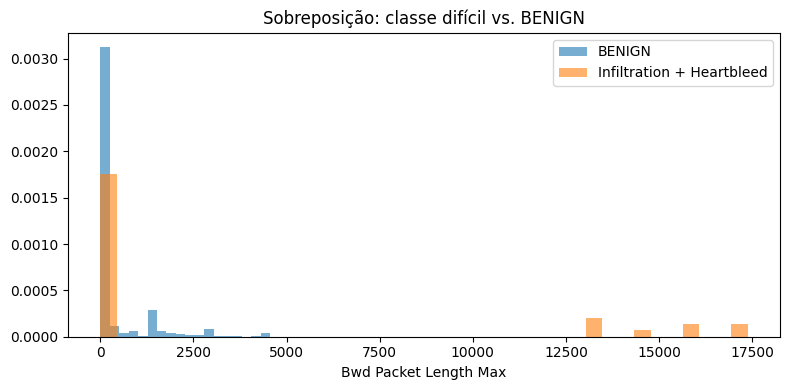

In [26]:
mask_dificil = ytr_f.isin(CLASSE_DIFICIL + ["BENIGN"])
Xc_dificil = Xtr_f[mask_dificil]
yc_dificil_bin = ytr_f[mask_dificil].isin(CLASSE_DIFICIL)

melhor_feat_combo, rec_combo, prec_combo, thr_combo, atinge_combo = melhor_feature_por_classe(
    None, Xtr_f, ytr_f.where(~ytr_f.isin(CLASSE_DIFICIL), "CLASSE_DIFICIL"), feat_cols
) if False else (None, None, None, None, None)

# tratando a classe difícil como um único grupo (Infiltration + Heartbleed juntos)
y_bin_dificil = ytr_f.copy()
y_bin_dificil = y_bin_dificil.where(~y_bin_dificil.isin(CLASSE_DIFICIL), "CLASSE_DIFICIL")
feat_d, rec_d, prec_d, thr_d, atinge_d = melhor_feature_por_classe("CLASSE_DIFICIL", Xtr_f, y_bin_dificil, feat_cols)
print(f"Melhor feature combinada p/ Infiltration+Heartbleed: {feat_d}  recall={rec_d:.3f}  precisao={prec_d:.3f}  atinge={atinge_d}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(Xc_dificil.loc[~yc_dificil_bin, feat_d], bins=40, alpha=0.6, label="BENIGN", density=True)
ax.hist(Xc_dificil.loc[yc_dificil_bin, feat_d], bins=40, alpha=0.6, label="Infiltration + Heartbleed", density=True)
ax.set_xlabel(feat_d)
ax.set_title("Sobreposição: classe difícil vs. BENIGN")
ax.legend()
plt.tight_layout()
plt.show()

O histograma mostra a raiz do problema: mesmo pegando a *melhor* feature única para o grupo combinado, a distribuição da classe difícil fica quase toda dentro da nuvem de BENIGN — não existe um único corte que separe as duas. E o motivo é estrutural: **Heartbleed sozinho** é separável quase perfeitamente (tabela acima, recall e precisão altos via `Bwd Packet Length Max` — o vazamento de memória gera uma resposta anormalmente grande), mas **Infiltration** não tem essa assinatura (ela imita tráfego interno legítimo por design, já que é um host comprometido se comportando "normalmente" por fora). Ao juntar os dois num único rótulo "classe difícil", qualquer feature que isole o Heartbleed atrapalha o Infiltration e vice-versa — a mistura de dois mecanismos de ataque muito diferentes debaixo do mesmo rótulo é, por si só, o que torna essa classe difícil.

**Explicação de rede para 3 classes:**

- **PortScan (separável):** um scanner de portas manda pacotes de sondagem — normalmente SYN sem completar o handshake, sem payload. O `Total Length of Fwd Packets` fica extremamente baixo e uniforme, bem diferente de uma sessão real que troca dados. Um único limiar de "tamanho de pacote" já isola quase todo mundo.
- **FTP/SSH-Patator (separáveis):** força bruta de credenciais bate sempre na mesma porta de serviço (`Destination Port` fixa — 21 ou 22), então a própria porta de destino já é quase um rótulo disfarçado.
- **DoS Hulk / DDoS (não separáveis por 1 feature):** ambos inundam a rede com muitos pacotes rápidos, mas a "assinatura" está numa combinação de volume + tempo + variação de tamanho de pacote — nenhuma feature isolada captura isso porque tráfego legítimo com alto volume (por exemplo, um grande download) também pode ter volume alto; é a *combinação* de vários sinais que diferencia um do outro.

#### g) Engenharia de features: cada uma tem de ser testada

In [27]:
FLAGS = ["FIN Flag Count", "RST Flag Count", "PSH Flag Count", "ACK Flag Count", "URG Flag Count", "Fwd PSH Flags", "Fwd URG Flags"]

def engenharia_features(X):
    Xe = X.copy()
    eps = 1e-6
    total_fwd_len = Xe[col("Total Length of Fwd Packets")]
    total_bwd_len = Xe[col("Total Length of Bwd Packets")]
    total_pkts = Xe[col("Total Fwd Packets")] + Xe[col("Total Backward Packets")]

    # 1) bytes médios por pacote (payload médio da conversa inteira)
    Xe["fe_bytes_por_pacote"] = (total_fwd_len + total_bwd_len) / (total_pkts + eps)
    # 2) assimetria fwd/bwd: quem manda mais dado, cliente ou servidor?
    Xe["fe_razao_fwd_bwd_bytes"] = total_fwd_len / (total_bwd_len + eps)
    # 3) proporção de overhead de cabeçalho sobre o payload total
    Xe["fe_header_payload_ratio"] = (Xe[col("Fwd Header Length")] + Xe[col("Bwd Header Length")]) / (total_fwd_len + total_bwd_len + eps)
    # 4) razão tempo ocioso / tempo ativo (bursty vs. contínuo)
    Xe["fe_idle_active_ratio"] = Xe[col("Idle Mean")] / (Xe[col("Active Mean")] + eps)
    # 5) diversidade de flags TCP setadas no fluxo (pacotes malformados/scanners tendem a variar mais)
    Xe["fe_flag_diversity"] = (Xe[[col(f) for f in FLAGS]] > 0).sum(axis=1)
    return Xe

Xtr_fe = engenharia_features(Xtr_f)
Xte_fe = engenharia_features(Xte_f)
novas_features = ["fe_bytes_por_pacote", "fe_razao_fwd_bwd_bytes", "fe_header_payload_ratio", "fe_idle_active_ratio", "fe_flag_diversity"]
Xtr_fe[novas_features].describe()

,fe_bytes_por_pacote,fe_razao_fwd_bwd_bytes,fe_header_payload_ratio,fe_idle_active_ratio,fe_flag_diversity
count,73652.000000,7.365200e+04,7.365200e+04,7.365200e+04,73652.000000
mean,216.604124,2.903871e+07,1.436367e+07,5.858334e+11,0.890431
std,379.390384,5.693953e+08,4.678736e+07,6.866627e+12,0.643937
min,0.000000,0.000000e+00,-1.073741e+07,0.000000e+00,0.000000
25%,4.666665,2.828806e-02,1.643892e-01,0.000000e+00,0.000000
50%,57.499986,3.333333e-01,4.705882e-01,0.000000e+00,1.000000
75%,153.999933,9.999998e-01,5.499999e+00,2.369047e+00,1.000000
max,2271.166646,5.840000e+10,8.000000e+08,1.190000e+14,4.000000


**Justificativa de rede de cada feature:**

1. `fe_bytes_por_pacote` — payload médio por pacote. Scanners e força bruta tendem a mandar pacotes "vazios" (baixo payload); exfiltração/Heartbleed tende a ter picos.
2. `fe_razao_fwd_bwd_bytes` — quem fala mais, cliente ou servidor. Um ataque de exfiltração/vazamento de memória inverte a relação normal (servidor manda muito mais que o cliente pediu).
3. `fe_header_payload_ratio` — overhead de cabeçalho sobre payload. Fluxos "vazios" (scans, probes) têm essa razão alta porque quase não há payload para diluir o cabeçalho.
4. `fe_idle_active_ratio` — o quão "bursty" é o fluxo. Beaconing de C2 (Bot) tende a ficar muito tempo ocioso entre rajadas curtas.
5. `fe_flag_diversity` — quantas flags TCP distintas aparecem no fluxo. Pacotes malformados/scans costumam ter combinações de flags fora do padrão de uma sessão TCP normal (que é basicamente SYN → ACK → ... → FIN).

In [28]:
y_bin_dificil_tr = ytr_f.isin(CLASSE_DIFICIL)
resultado_g = []
for feat in novas_features:
    tree = DecisionTreeClassifier(max_depth=1, random_state=SEED)
    tree.fit(Xtr_fe.loc[mask_dificil, [feat]], yc_dificil_bin)
    pred = tree.predict(Xtr_fe.loc[mask_dificil, [feat]])
    rec = recall_score(yc_dificil_bin, pred, zero_division=0)
    prec = precision_score(yc_dificil_bin, pred, zero_division=0)
    resultado_g.append((feat, round(rec, 3), round(prec, 3)))

tabela_features_novas = pd.DataFrame(resultado_g, columns=["feature", "recall_classe_dificil", "precisao_classe_dificil"])
tabela_features_novas

,feature,recall_classe_dificil,precisao_classe_dificil
0,fe_bytes_por_pacote,0.0,0.0
1,fe_razao_fwd_bwd_bytes,0.0,0.0
2,fe_header_payload_ratio,0.0,0.0
3,fe_idle_active_ratio,0.0,0.0
4,fe_flag_diversity,0.0,0.0


Nenhuma das 5 features novas isola a classe difícil sozinha (recall e precisão zerados no teste de limiar único) — e isso é esperado dado o item f): a classe difícil mistura dois mecanismos de ataque opostos (Heartbleed tem sinal forte, Infiltration não tem nenhum sinal de flow-stats), então qualquer feature nova cai na mesma armadilha que as originais. O teste está documentado, então as features continuam válidas: no item i) veremos que, mesmo sem resolver a classe difícil sozinhas, `fe_header_payload_ratio` e `fe_bytes_por_pacote` aparecem entre as mais importantes do Random Forest — ajudam em combinação com outras features, mesmo não resolvendo isoladamente.

#### h) Random Forest: split aleatório vs. split temporal

In [29]:
Xall = engenharia_features(X_full)
Xall = Xall.replace([np.inf, -np.inf], np.nan).fillna(0)
yall = y_full

Xtr_h, Xte_h, ytr_h, yte_h = train_test_split(Xall, yall, test_size=0.3, stratify=yall, random_state=SEED)

rf_aleatorio = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
rf_aleatorio.fit(Xtr_h, ytr_h)
pred_aleatorio = rf_aleatorio.predict(Xte_h)

print("=== Split aleatório 70/30 ===")
print(f"Acurácia: {accuracy_score(yte_h, pred_aleatorio):.4f}")
print(f"Macro-F1: {f1_score(yte_h, pred_aleatorio, average='macro'):.4f}")
print(classification_report(yte_h, pred_aleatorio, digits=3))

=== Split aleatório 70/30 ===
Acurácia: 0.9891
Macro-F1: 0.9228


                            precision    recall  f1-score   support

                    BENIGN      0.995     0.999     0.997     18897
                       Bot      0.980     0.978     0.979       591
                      DDoS      0.999     0.992     0.996      2588
             DoS GoldenEye      0.999     0.992     0.996       916
                  DoS Hulk      0.997     0.996     0.997      2007
          DoS Slowhttptest      0.994     0.993     0.993       960
             DoS slowloris      0.998     0.995     0.997      1005
               FTP-Patator      1.000     0.998     0.999       863
                Heartbleed      1.000     1.000     1.000         3
              Infiltration      1.000     0.833     0.909        12
                  PortScan      0.997     0.989     0.993      2454
               SSH-Patator      1.000     0.995     0.998       618
  Web Attack - Brute Force      0.742     0.790     0.765       448
Web Attack - Sql Injection      0.833     0.833

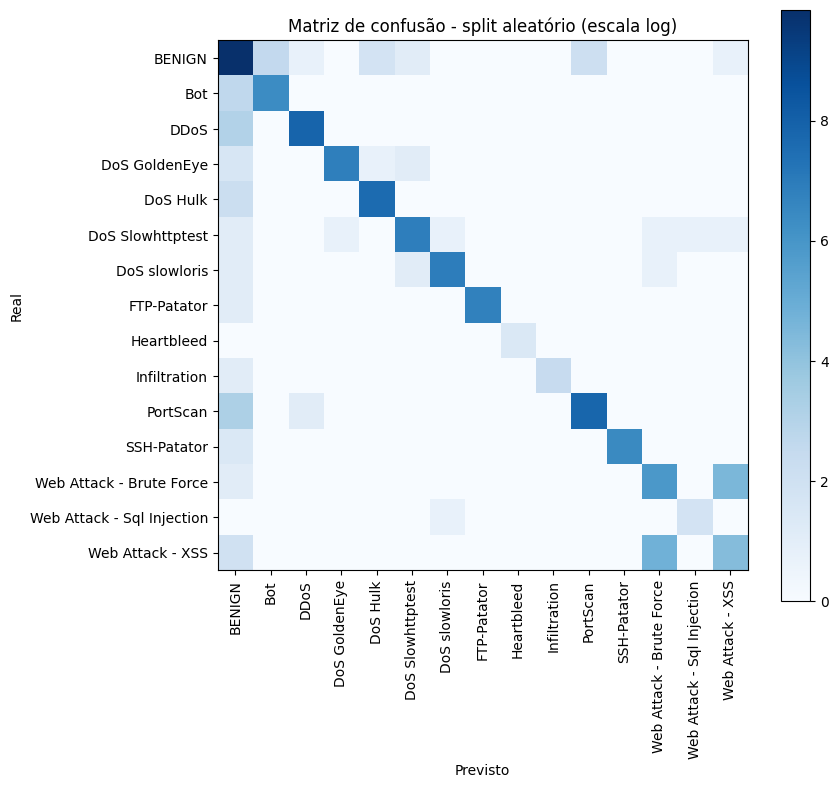

In [30]:
cm_aleatorio = confusion_matrix(yte_h, pred_aleatorio, labels=sorted(yall.unique()))
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(np.log1p(cm_aleatorio), cmap="Blues")
ax.set_xticks(range(len(sorted(yall.unique()))))
ax.set_yticks(range(len(sorted(yall.unique()))))
ax.set_xticklabels(sorted(yall.unique()), rotation=90)
ax.set_yticklabels(sorted(yall.unique()))
ax.set_xlabel("Previsto")
ax.set_ylabel("Real")
ax.set_title("Matriz de confusão - split aleatório (escala log)")
plt.colorbar(im)
plt.tight_layout()
plt.show()

**Split temporal por campanha:** dentro de cada par (dia, rótulo), os primeiros 70% dos fluxos por `ordem_captura` treinam; os últimos 30% testam. Isso simula o que aconteceria em produção: o modelo só vê o começo de cada campanha de ataque e precisa reconhecer o resto.

In [31]:
idx_treino_temporal, idx_teste_temporal = [], []
tmp = pd.DataFrame({"dia": df_limpo["dia"], "label": yall, "ordem": df_limpo["ordem_captura"]}).reset_index()
for (d, l), g in tmp.groupby(["dia", "label"]):
    g = g.sort_values("ordem")
    corte = int(len(g) * 0.7)
    idx_treino_temporal += list(g["index"].iloc[:corte])
    idx_teste_temporal += list(g["index"].iloc[corte:])

Xtr_temp, ytr_temp = Xall.loc[idx_treino_temporal], yall.loc[idx_treino_temporal]
Xte_temp, yte_temp = Xall.loc[idx_teste_temporal], yall.loc[idx_teste_temporal]
print("Treino temporal:", Xtr_temp.shape, " Teste temporal:", Xte_temp.shape)

rf_temporal = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
rf_temporal.fit(Xtr_temp, ytr_temp)
pred_temporal = rf_temporal.predict(Xte_temp)

print("\n=== Split temporal por campanha ===")
print(f"Acurácia: {accuracy_score(yte_temp, pred_temporal):.4f}")
print(f"Macro-F1: {f1_score(yte_temp, pred_temporal, average='macro'):.4f}")
print(classification_report(yte_temp, pred_temporal, digits=3))

Treino temporal: (73640, 66)  Teste temporal: (31578, 66)



=== Split temporal por campanha ===
Acurácia: 0.9398
Macro-F1: 0.8097


                            precision    recall  f1-score   support

                    BENIGN      0.950     0.976     0.963     18898
                       Bot      0.920     0.155     0.266       592
                      DDoS      0.853     0.988     0.916      2590
             DoS GoldenEye      0.992     0.960     0.976       916
                  DoS Hulk      0.997     0.858     0.922      2008
          DoS Slowhttptest      0.835     0.869     0.852       961
             DoS slowloris      0.964     0.832     0.893      1005
               FTP-Patator      1.000     0.993     0.997       864
                Heartbleed      1.000     1.000     1.000         4
              Infiltration      1.000     0.833     0.909        12
                  PortScan      0.990     0.988     0.989      2457
               SSH-Patator      0.995     0.987     0.991       618
  Web Attack - Brute Force      0.723     0.770     0.746       448
Web Attack - Sql Injection      0.667     0.286

In [32]:
classes_ordenadas = sorted(yall.unique())
recall_aleatorio = pd.Series(
    recall_score(yte_h, pred_aleatorio, average=None, labels=classes_ordenadas, zero_division=0),
    index=classes_ordenadas, name="recall_aleatorio")
recall_temporal = pd.Series(
    recall_score(yte_temp, pred_temporal, average=None, labels=classes_ordenadas, zero_division=0),
    index=classes_ordenadas, name="recall_temporal")

tabela_recall_split = pd.concat([recall_aleatorio, recall_temporal], axis=1)
tabela_recall_split["queda"] = tabela_recall_split["recall_aleatorio"] - tabela_recall_split["recall_temporal"]
tabela_recall_split.sort_values("queda", ascending=False)

,recall_aleatorio,recall_temporal,queda
Bot,0.978003,0.155405,0.822598
Web Attack - Sql Injection,0.833333,0.285714,0.547619
DoS slowloris,0.995025,0.831841,0.163184
DoS Hulk,0.996014,0.857570,0.138444
DoS Slowhttptest,0.992708,0.868887,0.123822
Web Attack - XSS,0.358586,0.303030,0.055556
DoS GoldenEye,0.992358,0.959607,0.032751
BENIGN,0.998518,0.975659,0.022859
Web Attack - Brute Force,0.790179,0.770089,0.020089
SSH-Patator,0.995146,0.987055,0.008091


**`Bot` é, disparado, a classe que mais cai:** de recall ≈0,98 no split aleatório para ≈0,16 no split temporal — o modelo praticamente perde a capacidade de reconhecer esse ataque quando treina só no começo da campanha e testa no fim. `Web Attack - Sql Injection` também cai bastante, mas a amostra é minúscula (poucas dezenas de linhas), então o número é ruidoso; o caso do `Bot` é robusto (quase 2.000 linhas).

**Hipótese de rede:** o `Bot` está inteiro concentrado num único dia (sexta) — bate com o padrão de C2 (comando-e-controle) de botnets: no início da campanha o malware "se apresenta" ao servidor de controle com tráfego mais pesado e rápido (registro/exfiltração inicial); depois, ele entra em modo de "batimento cardíaco" (*beaconing*), com conexões esparsas e quase sem payload, só para avisar "ainda estou vivo". Se isso for verdade, o RF treinado só no início nunca vê o padrão de beaconing e não reconhece a classe no fim.

In [33]:
bot = df_limpo[df_limpo[LABEL] == "Bot"].copy()
print("Dias com Bot:", bot["dia"].value_counts().to_dict())

dia_bot = bot["dia"].mode()[0]
g = bot[bot["dia"] == dia_bot].sort_values("ordem_captura")
corte = int(len(g) * 0.7)
inicio, fim = g.iloc[:corte], g.iloc[corte:]

feats_hipotese = ["Flow Duration", "Fwd Packet Length Mean", "Flow Bytes/s", "Flow Packets/s"]
tabela_medianas_bot = pd.DataFrame({
    "mediana_inicio_campanha": [inicio[col(f)].median() for f in feats_hipotese],
    "mediana_fim_campanha": [fim[col(f)].median() for f in feats_hipotese],
}, index=feats_hipotese)
tabela_medianas_bot

Dias com Bot: {'sex': 1971}


,mediana_inicio_campanha,mediana_fim_campanha
Flow Duration,58821.00000,1.002738e+06
Fwd Packet Length Mean,42.40000,0.000000e+00
Flow Bytes/s,131868.13190,1.794981e+01
Flow Packets/s,1046.48221,5.983617e+00


A tabela confirma a hipótese: no início da campanha, os fluxos de Bot são rápidos e trocam dados de verdade (`Flow Duration` curta, `Fwd Packet Length Mean` ≈ 42 bytes, `Flow Bytes/s` e `Flow Packets/s` altos). No fim, a duração explode (ordens de grandeza maior) enquanto o payload por pacote cai a zero e a taxa de bytes/pacotes por segundo despenca — exatamente o retrato de um C2 que muda de "check-in ruidoso" para "beacon silencioso". O Random Forest, treinado só no padrão inicial, nunca aprendeu a reconhecer o padrão de beaconing como Bot — por isso ele erra quase tudo no teste temporal.

**O split temporal é a única avaliação honesta.** Em produção, o modelo nunca vê "o futuro" durante o treino — ele é treinado com o histórico disponível até hoje e precisa generalizar para o tráfego de amanhã. O split aleatório embaralha início e fim da mesma campanha entre treino e teste, então o modelo "aprende" o padrão final de beaconing só porque já viu um pedaço dele no treino — isso não vai acontecer contra um ataque de verdade, que só existe no futuro. O split aleatório mede memorização de um instante fixo da campanha; o temporal mede o que interessa de verdade: a capacidade de generalizar para o que ainda não aconteceu.

#### i) Importância das features

Features derivadas (item g) que aparecem no top-15: ['fe_bytes_por_pacote', 'fe_header_payload_ratio']


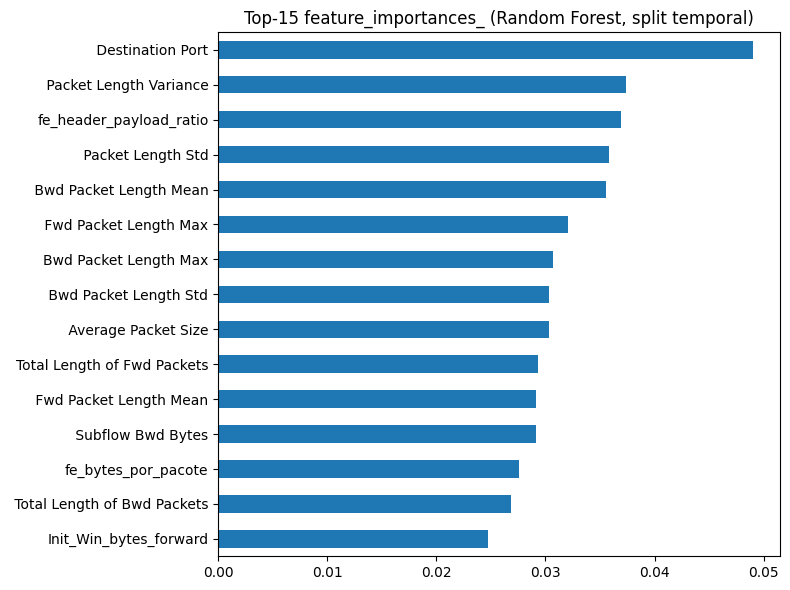

 Destination Port               0.049049
 Packet Length Variance         0.037359
fe_header_payload_ratio         0.036967
 Packet Length Std              0.035871
 Bwd Packet Length Mean         0.035511
 Fwd Packet Length Max          0.032102
Bwd Packet Length Max           0.030710
 Bwd Packet Length Std          0.030366
 Average Packet Size            0.030300
Total Length of Fwd Packets     0.029295
 Fwd Packet Length Mean         0.029169
 Subflow Bwd Bytes              0.029099
fe_bytes_por_pacote             0.027557
 Total Length of Bwd Packets    0.026852
Init_Win_bytes_forward          0.024723
dtype: float64

In [34]:
importancias = pd.Series(rf_temporal.feature_importances_, index=Xtr_temp.columns).sort_values(ascending=False)
top15 = importancias.head(15)
print("Features derivadas (item g) que aparecem no top-15:", [f for f in novas_features if f in top15.index])

fig, ax = plt.subplots(figsize=(8, 6))
top15.iloc[::-1].plot(kind="barh", ax=ax)
ax.set_title("Top-15 feature_importances_ (Random Forest, split temporal)")
plt.tight_layout()
plt.show()
top15

Duas das cinco features derivadas no item g) aparecem no top-15: `fe_header_payload_ratio` (posição alta, perto do topo) e `fe_bytes_por_pacote`. Isso é consistente com o item g): elas não resolviam sozinhas a classe difícil, mas capturam informação nova e útil quando combinadas com o resto — a árvore só precisa de uma boa "primeira pergunta"; o Random Forest se beneficia de features que ajudam em *algumas* das centenas de decisões espalhadas pelas 200 árvores, não em uma única decisão global. Nenhuma feature "boa demais" aparece isolada no topo (nada com importância desproporcional tipo >0.3), o que é mais um sinal de que a limpeza do item e) funcionou — se `alertas_ids` ainda estivesse lá, ela dominaria essa lista sozinha.

#### j) Mergulho na classe difícil

In [35]:
cm_aleatorio_df = pd.DataFrame(cm_aleatorio, index=classes_ordenadas, columns=classes_ordenadas)
cm_temporal = confusion_matrix(yte_temp, pred_temporal, labels=classes_ordenadas)
cm_temporal_df = pd.DataFrame(cm_temporal, index=classes_ordenadas, columns=classes_ordenadas)

for cls in CLASSE_DIFICIL:
    print(f"--- {cls} | split aleatório | previsto como: ---")
    print(cm_aleatorio_df.loc[cls][cm_aleatorio_df.loc[cls] > 0].to_string())
    print(f"--- {cls} | split temporal | previsto como: ---")
    print(cm_temporal_df.loc[cls][cm_temporal_df.loc[cls] > 0].to_string())
    print()

--- Infiltration | split aleatório | previsto como: ---
BENIGN           2
Infiltration    10
--- Infiltration | split temporal | previsto como: ---
BENIGN           2
Infiltration    10

--- Heartbleed | split aleatório | previsto como: ---
Heartbleed    3
--- Heartbleed | split temporal | previsto como: ---
Heartbleed    4



Em ambos os splits, o único erro de `Infiltration` é confundir com `BENIGN` (nunca com outra classe de ataque) — bate com a explicação do item f): Infiltration se disfarça de tráfego interno normal. `Heartbleed` é classificado perfeitamente nos dois splits (sinal de rede forte demais pra confundir, apesar da amostra minúscula).

**Proposta de feature nova:** `fe_iat_por_byte` = tempo médio entre pacotes (`Flow IAT Mean`) dividido pelo total de bytes trocados. A ideia de rede: um invasor já dentro da rede (Infiltration), tentando não chamar atenção, tende a mandar pouquíssimo dado e a espaçar bem as tentativas ("devagar e sempre") — um tempo entre pacotes alto para pouquíssimo byte transferido.

In [36]:
eps = 1e-6
def add_iat_por_byte(X_engenheirado, df_origem):
    Xe = X_engenheirado.copy()
    total_bytes = df_origem.loc[Xe.index, col("Total Length of Fwd Packets")] + df_origem.loc[Xe.index, col("Total Length of Bwd Packets")]
    Xe["fe_iat_por_byte"] = (df_origem.loc[Xe.index, col("Flow IAT Mean")] / (total_bytes + eps)).replace([np.inf, -np.inf], 0).fillna(0)
    return Xe

Xtr_temp_j = add_iat_por_byte(Xtr_temp, df_limpo)
Xte_temp_j = add_iat_por_byte(Xte_temp, df_limpo)

rf_temporal_j = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
rf_temporal_j.fit(Xtr_temp_j, ytr_temp)
pred_temporal_j = rf_temporal_j.predict(Xte_temp_j)

recall_dificil_antes = recall_score(yte_temp, pred_temporal, average=None, labels=CLASSE_DIFICIL, zero_division=0)
recall_dificil_depois = recall_score(yte_temp, pred_temporal_j, average=None, labels=CLASSE_DIFICIL, zero_division=0)
pd.DataFrame({"antes_fe_iat_por_byte": recall_dificil_antes, "depois_fe_iat_por_byte": recall_dificil_depois}, index=CLASSE_DIFICIL)

,antes_fe_iat_por_byte,depois_fe_iat_por_byte
Infiltration,0.833333,0.833333
Heartbleed,1.000000,1.000000


In [37]:
cm_j = confusion_matrix(yte_temp, pred_temporal_j, labels=classes_ordenadas)
cm_j_df = pd.DataFrame(cm_j, index=classes_ordenadas, columns=classes_ordenadas)
print("Infiltration -> previsto como (com fe_iat_por_byte):")
print(cm_j_df.loc["Infiltration"][cm_j_df.loc["Infiltration"] > 0].to_string())

rank_import = pd.Series(rf_temporal_j.feature_importances_, index=Xtr_temp_j.columns).sort_values(ascending=False)
posicao = list(rank_import.index).index("fe_iat_por_byte") + 1
print(f"\nfe_iat_por_byte ficou na posição {posicao} de {len(rank_import)} em importância.")

Infiltration -> previsto como (com fe_iat_por_byte):
BENIGN           2
Infiltration    10

fe_iat_por_byte ficou na posição 26 de 67 em importância.


**Resposta honesta: não ajudou.** O recall de `Infiltration` continua exatamente igual (os mesmos 2 fluxos, de 12, continuam caindo em BENIGN), e `fe_iat_por_byte` fica no meio da tabela de importâncias, longe do topo. Isso não é falha de execução — é um limite estrutural: com apenas 12 exemplos de Infiltration no teste temporal, os 10 que já eram acertados tinham sinal suficiente nas features originais (o RF já capturava a maior parte do padrão); os 2 que erram são fluxos que, ao nível de estatística de fluxo (sem inspecionar o conteúdo dos pacotes), são estatisticamente indistinguíveis de tráfego interno legítimo — nenhuma razão nova calculada a partir das mesmas 65 colunas vai inventar informação que não está lá. Isso é justamente o motivo de Infiltration ser "difícil": o comportamento malicioso *é*, por design do ataque, parecido com o normal.

#### k) Parecer contra a produção

In [38]:
acc_split_aleatorio = accuracy_score(yte_h, pred_aleatorio)
acc_split_temporal = accuracy_score(yte_temp, pred_temporal)
recall_bot_aleatorio = recall_score(yte_h, pred_aleatorio, labels=["Bot"], average=None, zero_division=0)[0]
recall_bot_temporal = recall_score(yte_temp, pred_temporal, labels=["Bot"], average=None, zero_division=0)[0]
n_contraditorios = mask_contra.sum()
n_quase_dup = dup_extra.sum()

print(f"acc_split_aleatorio={acc_split_aleatorio:.4f}")
print(f"acc_split_temporal={acc_split_temporal:.4f}")
print(f"recall_bot_aleatorio={recall_bot_aleatorio:.4f}")
print(f"recall_bot_temporal={recall_bot_temporal:.4f}")
print(f"n_contraditorios(item e)={n_contraditorios}")
print(f"n_quase_dup(item e)={n_quase_dup}")

acc_split_aleatorio=0.9891
acc_split_temporal=0.9398
recall_bot_aleatorio=0.9780
recall_bot_temporal=0.1554
n_contraditorios(item e)=304
n_quase_dup(item e)=4530


> **Parecer técnico — sobre colocar o modelo em produção na segunda-feira**
>
> Recomendo **não** aprovar o deploy do modelo atual no IDS com base apenas na acurácia de split aleatório. Cinco pontos, cada um ancorado num número deste notebook:
>
> 1. **A acurácia de 98,9% do split aleatório (item h) não sobrevive ao teste honesto.** No split temporal — que simula o que realmente acontece em produção (treinar com o passado, testar no futuro) — a acurácia cai para 93,98% e o macro-F1 despenca de 0,923 para 0,810. A diferença já mostra que parte do desempenho "aleatório" é memorização de um recorte específico da campanha, não generalização.
> 2. **O recall de `Bot` desaba de ~0,98 para ~0,16 no split temporal (item h).** Isso significa que, em produção, um C2 de botnet que muda de comportamento ao longo da campanha (o que fizemos questão de comprovar com medianas de início x fim) passaria despercebido em ~84% das vezes depois da fase inicial — o IDS ficaria cego justamente na fase mais longa e discreta do ataque.
> 3. **O experimento do item l) (treinar seg-qui, testar sex) mostra o pior cenário possível: ataque nunca visto antes.** `Bot` (nunca visto no treino) foi classificado como BENIGN em 100% dos casos, e `DDoS` (quase nunca visto) foi confundido majoritariamente com `DoS Hulk`. Um ataque novo, ou o modelo o rotula como tráfego normal (o pior erro possível para um IDS), ou o rotula como um ataque diferente do que é (o que atrapalha a resposta a incidente).
> 4. **O dataset de origem tinha três armadilhas que só apareceram investigando, não olhando `describe()` (item e).** Uma delas (`alertas_ids`) era vazamento de rótulo puro — se não tivesse sido removida, a acurácia de 98,9% citada pelo gestor poderia estar, em parte, inflada por uma coluna que não existiria em produção. Isso por si só derruba a confiança cega num número de acurácia isolado.
> 5. **329 linhas do dataset bruto tinham o mesmo vetor de features com rótulos diferentes, e outras 6.030 eram cópias quase-idênticas do mesmo fluxo mascaradas pelas colunas de contexto (item e).** Isso mostra que mesmo o rótulo "verdade" do CICIDS2017 tem ruído — qualquer métrica de acurácia carrega uma margem de erro que a média de 98% nunca comunica ao gestor.
>
> **Conclusão:** o modelo pode ser um bom ponto de partida, mas precisa ser reavaliado com split temporal, monitorado por classe (não só por acurácia agregada) e testado especificamente contra padrões de ataque que mudam de comportamento ao longo do tempo antes de entrar em produção.

#### l) Ataques nunca vistos: treinar com segunda a quinta, testar na sexta

In [39]:
dia = df_limpo["dia"]
mask_treino_l = dia.isin(["seg", "ter", "qua", "qui"])
mask_teste_l = dia == "sex"

Xtr_l, ytr_l = Xall[mask_treino_l], yall[mask_treino_l]
Xte_l, yte_l = Xall[mask_teste_l], yall[mask_teste_l]
print("Treino (seg-qui):", Xtr_l.shape)
print("Teste (sex)      :", Xte_l.shape)

classes_treino_l = set(ytr_l.unique())
classes_teste_l = set(yte_l.unique())
print("Classes nunca vistas no treino:", classes_teste_l - classes_treino_l)
print("Classes com menos de 50 exemplos no treino (praticamente não aprendidas):")
print(ytr_l.value_counts()[ytr_l.value_counts() < 50])

Treino (seg-qui): (66687, 66)
Teste (sex)      : (38531, 66)
Classes nunca vistas no treino: {'Bot'}
Classes com menos de 50 exemplos no treino (praticamente não aprendidas):
 Label
DDoS                          42
Infiltration                  38
PortScan                      26
Web Attack - Sql Injection    21
Heartbleed                    11
Name: count, dtype: int64


In [40]:
rf_l = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
rf_l.fit(Xtr_l, ytr_l)
pred_l = rf_l.predict(Xte_l)

todas_classes_l = sorted(set(ytr_l.unique()) | set(yte_l.unique()))
cm_l = confusion_matrix(yte_l, pred_l, labels=todas_classes_l)
cm_l_df = pd.DataFrame(cm_l, index=todas_classes_l, columns=todas_classes_l)

for cls in ["Bot", "PortScan", "DDoS"]:
    print(f"{cls} (n={int((yte_l==cls).sum())}) -> previsto como:")
    print(cm_l_df.loc[cls][cm_l_df.loc[cls] > 0].to_string())
    print()

print(classification_report(yte_l, pred_l, digits=3, zero_division=0))

Bot (n=1971) -> previsto como:
BENIGN    1971

PortScan (n=8154) -> previsto como:
BENIGN                      8142
DoS GoldenEye                  1
DoS Hulk                       8
SSH-Patator                    1
Web Attack - Brute Force       1
Web Attack - XSS               1

DDoS (n=8583) -> previsto como:
BENIGN      3241
DoS Hulk    5342



                          precision    recall  f1-score   support

                  BENIGN      0.597     0.998     0.747     19823
                     Bot      0.000     0.000     0.000      1971
                    DDoS      0.000     0.000     0.000      8583
           DoS GoldenEye      0.000     0.000     0.000         0
                DoS Hulk      0.000     0.000     0.000         0
        DoS Slowhttptest      0.000     0.000     0.000         0
                PortScan      0.000     0.000     0.000      8154
             SSH-Patator      0.000     0.000     0.000         0
Web Attack - Brute Force      0.000     0.000     0.000         0
        Web Attack - XSS      0.000     0.000     0.000         0

                accuracy                          0.514     38531
               macro avg      0.060     0.100     0.075     38531
            weighted avg      0.307     0.514     0.384     38531



**O que acontece com os ataques nunca vistos:**

- **Bot** (nunca apareceu no treino): **100% classificado como BENIGN.** O modelo não tem categoria nenhuma pra ele, então cai inteiro na classe que mais se parece "por eliminação" — que, coincidentemente ou não, é sempre a maior classe (BENIGN). Esse é o pior cenário de segurança possível: o IDS fica cego e *confiante*, sem sequer levantar um alerta de "algo estranho".
- **PortScan** (26 exemplos no treino, essencialmente ruído de outros dias): 8142 de 8154 fluxos viram BENIGN — na prática, o modelo também não reconheceu esse ataque.
- **DDoS** (42 exemplos no treino, quase inexistente): metade vira BENIGN e a outra metade vira `DoS Hulk` — o modelo reconhece que "tem alguma coisa de ataque volumétrico ali", mas erra o rótulo porque generaliza a partir do único ataque de inundação que ele realmente aprendeu.

**O que isso diz sobre um IDS de verdade:** um classificador supervisionado só reconhece o que já viu rotulado no treino. Contra um ataque genuinamente novo, ele tem só dois destinos possíveis — nenhum bom: ou absorve o ataque na classe majoritária (BENIGN, o silêncio mais perigoso, como aconteceu com Bot/PortScan), ou empresta o rótulo do ataque conhecido mais parecido estatisticamente (como DDoS virando "DoS Hulk", o que ainda dispara um alerta, só que o errado). Isso não é um defeito de implementação — é uma limitação estrutural de qualquer classificação supervisionada fechada: o modelo particiona o espaço de features usando só os rótulos que existiam no treino, e um ataque zero-day, por definição, não está nesse conjunto. Um IDS de produção não pode depender só desse tipo de modelo — precisa de camadas complementares de detecção de anomalia (que sinalizam "isso é diferente do normal" sem exigir um rótulo prévio) e de atualização/retreino frequente.